# M9.1 · Device Behavior Clustering (CRISP-DM Phase 4)

**Goal.** Discover device-behavior **archetypes** without labels.
Project success criterion (clustering half): *"clusters reveal at least 3 distinct driver behavior profiles."*

**Scope decisions enforced here (from EDA verdict 2026-04-30):**
- **F3** — Restrict to `year_month >= '2025-01'`. Pre-2025 the archive-derived signals (harsh events, telemetry, RPM, idle) are effectively absent (~99% of those rows are 2025+).
- **F4** — **Per-tenant** clustering. Tenants 264 (overspeed-rich) and 1787 (harsh-rich) are different operating regimes; a single global cluster space averages them out and produces meaningless centroids.
- **F5** — Unit of analysis is the **device-month**, not the driver. Driver attribution covers 12 of 633 devices in source.
- **F6** — Unsupervised only. The `>0.7` correlation hypothesis is contradicted by the data (harsh ↔ overspeed are inversely correlated globally). We use clustering + anomaly detection (notebook 02).

**Pipeline:**
1. Pull `v_ml_features_full` filtered to >= 2025-01 with full signal.
2. Per tenant: scale → PCA(2) → KMeans(k=3..6) → silhouette → pick best k.
3. Cluster-profile table + 2D scatter plot per tenant.
4. Persist labelled rows to `data/ml/device_clusters.parquet`.

In [1]:
from __future__ import annotations
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name != 'accent-fleet-analytics' else pathlib.Path().resolve()
for c in (PROJECT_ROOT, PROJECT_ROOT.parent):
    src = c / 'src'
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src)); break

import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from accent_fleet.db import get_engine
from sqlalchemy import text

## 2. Inputs

**Modeling window: 2025-01 onward** (F3). **Active rows only:** `total_distance_km >= 100` and `total_ignition_on_minutes > 0` (remove device-months that didn't move — they would form a degenerate "inactive" cluster that swamps the silhouette).

In [2]:
FEATURES = [
    'overspeed_per_100km', 'avg_speed_over_limit', 'high_speed_trip_ratio',
    'speed_alert_per_100km',
    'harsh_brake_per_100km', 'harsh_accel_per_100km', 'harsh_corner_per_100km',
    'monthly_idle_ratio', 'high_rpm_minutes_per_day',
    'night_trip_ratio', 'rush_hour_trip_ratio',
    'stddev_trip_distance', 'short_trip_ratio',
]
ID_COLS = ['tenant_id', 'device_id', 'year_month']

with get_engine().connect() as conn:
    df = pd.read_sql(text('''
        SELECT * FROM marts.v_ml_features_full
        WHERE year_month >= '2025-01'
          AND total_distance_km >= 100
          AND total_ignition_on_minutes > 0
    '''), conn)
print('rows:', len(df), 'tenants:', sorted(df.tenant_id.unique().tolist()))
print('rows per tenant:'); print(df.tenant_id.value_counts())

rows: 1723 tenants: [235, 238, 264, 1787]
rows per tenant:
tenant_id
235     613
1787    417
264     354
238     339
Name: count, dtype: int64


## 3. Per-tenant K-Means with silhouette-driven k selection (F4)

In [3]:
def fit_one_tenant(sub: pd.DataFrame, k_range=range(3, 7)):
    """Scale -> PCA(2 for plotting only) -> KMeans, choosing k by silhouette.
    Clustering itself runs in the original (scaled) feature space, not on PCA."""
    X = sub[FEATURES].fillna(0).to_numpy()
    if len(X) < 50:
        return None
    Xs = StandardScaler().fit_transform(X)
    best = None
    for k in k_range:
        if k >= len(X):
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
        sil = silhouette_score(Xs, km.labels_)
        if best is None or sil > best['sil']:
            best = {'k': k, 'sil': sil, 'km': km, 'Xs': Xs}
    pca2 = PCA(n_components=2, random_state=42).fit_transform(best['Xs'])
    out = sub[ID_COLS].copy()
    out['cluster'] = best['km'].labels_
    out['pc1'] = pca2[:, 0]; out['pc2'] = pca2[:, 1]
    return {'best_k': best['k'], 'silhouette': best['sil'],
            'labels': out, 'centroids': best['km'].cluster_centers_}

results = {}
for tenant_id, sub in df.groupby('tenant_id'):
    r = fit_one_tenant(sub)
    if r is None:
        print(f'tenant {tenant_id}: only {len(sub)} rows — skipped'); continue
    results[tenant_id] = r
    print(f'tenant {tenant_id}: n={len(sub):>4d}  best_k={r["best_k"]}  silhouette={r["silhouette"]:.3f}')

tenant 235: n= 613  best_k=3  silhouette=0.355
tenant 238: n= 339  best_k=6  silhouette=0.237
tenant 264: n= 354  best_k=6  silhouette=0.174
tenant 1787: n= 417  best_k=6  silhouette=0.278


## 4. Cluster profiles (per tenant)

For each tenant, show the per-cluster **mean** of every feature so we can label the clusters semantically (e.g., "aggressive speeders", "efficient drivers", "high-idle commuters").

In [4]:
all_labels = []
for tenant_id, r in results.items():
    labels = r['labels'].merge(df[ID_COLS + FEATURES + ['total_distance_km']],
                                on=ID_COLS, how='left')
    all_labels.append(labels)
    profile = (labels.groupby('cluster')[FEATURES + ['total_distance_km']]
                      .mean().round(2))
    profile['n'] = labels.groupby('cluster').size()
    print(f'\n=== tenant {tenant_id} (k={r["best_k"]}, sil={r["silhouette"]:.3f}) ===')
    display(profile)
all_labels = pd.concat(all_labels, ignore_index=True)


=== tenant 235 (k=3, sil=0.355) ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio,total_distance_km,n
cluster,,,,,,,,,,,,,,,
0,0.05,0.16,0.01,0.0,3.40,3.67,4.97,0.11,2.41,0.11,0.23,21.28,0.38,2985.67,505
1,1.24,1.69,0.01,0.0,45.26,96.37,171.48,0.16,0.00,0.02,0.25,7.87,0.40,1964.26,30
2,2.80,5.51,0.03,0.0,4.41,3.83,3.32,0.14,7.30,0.16,0.22,35.31,0.34,5376.76,78



=== tenant 238 (k=6, sil=0.237) ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio,total_distance_km,n
cluster,,,,,,,,,,,,,,,
0,0.00,0.06,0.01,0.00,5.88,11.13,15.36,0.12,0.00,0.05,0.26,16.63,0.40,2289.06,123
1,0.00,0.00,0.01,0.05,6.04,7.00,4.48,0.14,39.98,0.13,0.20,33.83,0.40,3962.98,27
2,0.03,0.43,0.00,0.00,77.12,203.25,393.98,0.10,0.00,0.04,0.20,16.17,0.41,2222.80,7
3,0.43,4.34,0.10,0.00,1.34,1.64,1.32,0.05,0.00,0.08,0.23,17.73,0.27,3538.57,36
4,0.00,0.00,0.00,16.28,0.00,0.00,0.00,0.50,0.00,0.00,0.32,3.98,0.46,755.27,7
5,0.04,0.68,0.01,0.00,1.59,2.53,3.62,0.08,0.14,0.15,0.19,35.09,0.31,4342.62,139



=== tenant 264 (k=6, sil=0.174) ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio,total_distance_km,n
cluster,,,,,,,,,,,,,,,
0,0.87,3.31,0.00,7.00,1.16,1.25,44.06,0.15,0.0,0.13,0.24,42.03,0.38,8699.32,7
1,3.16,4.42,0.01,9.29,0.17,0.13,1.60,0.04,0.0,0.13,0.23,48.21,0.26,7301.87,122
2,6.72,4.68,0.01,0.60,0.30,0.19,0.75,0.04,0.0,0.18,0.21,42.18,0.30,9252.60,117
3,5.29,8.81,0.03,3.16,2.05,2.78,4.59,0.54,0.0,0.10,0.24,17.29,0.49,3116.08,27
4,4.80,4.59,0.01,4.32,5.99,9.95,6.18,0.17,0.0,0.10,0.26,37.85,0.46,7112.92,18
5,0.59,3.71,0.10,3.98,0.00,0.00,0.00,0.08,0.0,0.08,0.23,17.83,0.19,2780.71,63



=== tenant 1787 (k=6, sil=0.278) ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio,total_distance_km,n
cluster,,,,,,,,,,,,,,,
0,0.60,12.22,0.04,0.29,3.91,5.31,8.46,0.15,0.0,0.03,0.22,15.55,0.32,3170.91,28
1,0.00,0.00,0.04,0.00,7.13,8.09,9.75,0.08,0.0,0.25,0.23,47.20,0.32,5980.57,85
2,0.00,0.00,0.00,0.06,53.28,71.93,123.12,0.09,0.0,0.09,0.22,16.20,0.43,2717.25,55
3,0.00,0.00,0.11,2.40,1.36,1.49,3.35,0.08,0.0,0.08,0.22,17.42,0.31,2411.24,22
4,0.00,0.00,0.04,0.00,3.13,5.02,6.89,0.46,0.0,0.19,0.26,17.95,0.56,2600.52,18
5,0.01,0.33,0.02,0.12,3.11,3.77,8.85,0.10,0.0,0.04,0.23,11.11,0.37,2280.77,209


## 5. 2D scatter (PCA) per tenant

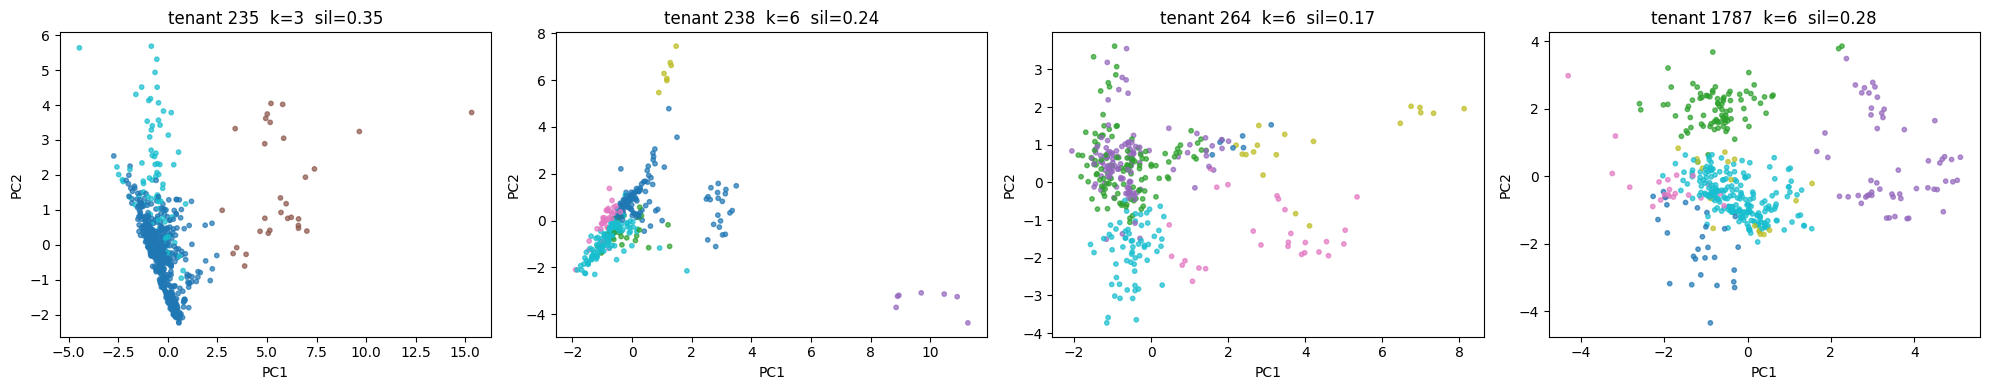

In [5]:
n = len(results)
if n:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for ax, (tenant_id, r) in zip(axes[0], results.items()):
        L = r['labels']
        ax.scatter(L.pc1, L.pc2, c=L.cluster, cmap='tab10', s=10, alpha=0.7)
        ax.set_title(f'tenant {tenant_id}  k={r["best_k"]}  sil={r["silhouette"]:.2f}')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.tight_layout(); plt.show()

## 6. Persist labels for downstream use

In [6]:
out_dir = pathlib.Path('../../data/ml'); out_dir.mkdir(parents=True, exist_ok=True)
all_labels[ID_COLS + ['cluster']].to_parquet(out_dir / 'device_clusters.parquet', index=False)
print('wrote', out_dir / 'device_clusters.parquet', 'rows:', len(all_labels))

wrote ..\..\data\ml\device_clusters.parquet rows: 1723


## 7. Exit gate

Project success criterion: *≥3 distinct profiles*. We pass if at least one tenant's best_k >= 3 AND silhouette >= 0.15 (a low bar appropriate for fleet behavior data).

In [7]:
passed = [(t, r) for t, r in results.items() if r['best_k'] >= 3 and r['silhouette'] >= 0.15]
print('tenants meeting gate:', [t for t, _ in passed], 'of', list(results.keys()))
assert passed, 'No tenant met the >=3 cluster, >=0.15 silhouette gate.'

tenants meeting gate: [235, 238, 264, 1787] of [235, 238, 264, 1787]
